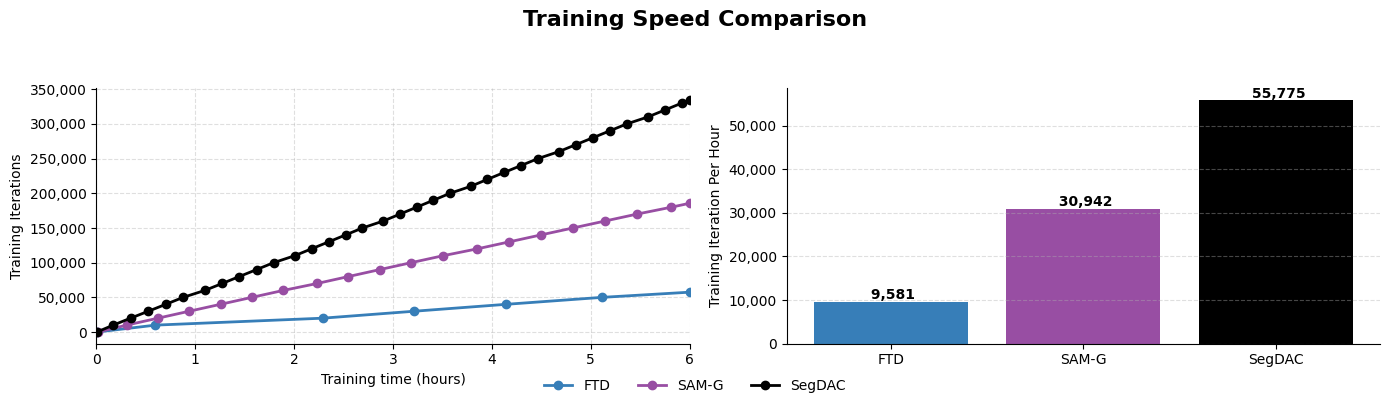

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------- Load JSON ----------------
json_path = "speed_analysis/env_step_duration.json"

with open(json_path, "r") as f:
    traces = json.load(f)

def get_method_label(raw_name: str) -> str:
    name = raw_name.lower()
    if "segdac" in name:
        return "SegDAC"
    if "ftd" in name:
        return "FTD"
    if "samg" in name or "sam-g" in name:
        return "SAM-G"
    return raw_name

# Colors: SegDAC black, FTD blue, SAM-G purple
method_colors = {
    "FTD":    "#377eb8",
    "SAM-G":  "#984ea3",
    "SegDAC": "#000000",
}

ordered_methods = ["FTD", "SAM-G", "SegDAC"]

# Duration = first 6 hours
MAX_SECONDS = 6 * 3600  # 21600

# ---- Load raw traces ----
method_raw = {}
for trace in traces:
    method = get_method_label(trace["name"])
    secs = np.asarray(trace["x"], dtype=float)
    env_steps = np.asarray(trace["y"], dtype=float)
    method_raw[method] = (secs, env_steps)

method_data = {}
env_at_6h = {}

for method in ordered_methods:
    secs, env_steps = method_raw[method]

    env_6h = float(np.interp(MAX_SECONDS, secs, env_steps))
    env_at_6h[method] = env_6h

    mask = (secs >= 0) & (secs <= MAX_SECONDS)
    secs_plot = secs[mask]
    env_plot = env_steps[mask]

    if len(secs_plot) == 0 or secs_plot[-1] < MAX_SECONDS:
        secs_plot = np.append(secs_plot, MAX_SECONDS)
        env_plot = np.append(env_plot, env_6h)

    method_data[method] = (secs_plot, env_plot)

env_per_hour = {m: env_at_6h[m] / 6.0 for m in ordered_methods}

def comma(x, pos):
    return f"{int(x):,}"

fig, (ax_line, ax_bar) = plt.subplots(1, 2, figsize=(14, 4))

for method in ordered_methods:
    secs_plot, env_plot = method_data[method]
    hours_plot = secs_plot / 3600.0

    ax_line.plot(
        hours_plot,
        env_plot,
        linewidth=2,
        marker="o",
        label=method,
        color=method_colors[method],
    )

ax_line.set_xlabel("Training time (hours)")
ax_line.set_ylabel("Training Iterations")
ax_line.set_xlim(0, MAX_SECONDS / 3600.0)
ax_line.grid(True, linestyle="--", alpha=0.4)
ax_line.yaxis.set_major_formatter(FuncFormatter(comma))
for spine in ["top", "right"]:
    ax_line.spines[spine].set_visible(False)

vals = [env_per_hour[m] for m in ordered_methods]
colors = [method_colors[m] for m in ordered_methods]
bars = ax_bar.bar(ordered_methods, vals, color=colors)

ax_bar.set_ylabel("Training Iteration Per Hour")
ax_bar.grid(axis="y", linestyle="--", alpha=0.4)
ax_bar.yaxis.set_major_formatter(FuncFormatter(comma))
for spine in ["top", "right"]:
    ax_bar.spines[spine].set_visible(False)

# Add exact values on top of bars
for bar, value in zip(bars, vals):
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(round(value)): ,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

handles, labels = ax_line.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Training Speed Comparison", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.92])

fig.savefig("speed_analysis/training_speed_plot.pdf")

plt.show()
